# DRUGseqPy — Notebook 1: Quality Control

Covers the complete QC workflow:
1. Data loading & object construction
2. Metadata validation
3. Per-sample library QC (UMI, genes, %mito, %ribo, HK genes, Gini)
4. Plate-level QC (Z'-factor, SSMD, spatial heatmaps)
5. Group-level QC and replicate ICC
6. Normalization comparison via RLE plots
7. Sample and gene filtering (group-aware)

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scanpy as sc

import drugseqpy as ds
from drugseqpy.utils import make_dummy_screen

sc.settings.verbosity = 1
plt.rcParams['figure.dpi'] = 100
print(f'drugseqpy v{ds.__version__}')

drugseqpy v0.1.0


## 1. Load data and create DrugSeqData

In [2]:
# Load your own data:
# counts = pd.read_csv('counts.csv', index_col=0)   # genes x samples
# obs    = pd.read_csv('metadata.csv', index_col=0) # samples x metadata

# Or generate synthetic data:
counts, obs = make_dummy_screen(
    n_genes=500, n_plates=2,
    n_dmso_per_plate=10, n_compounds=6, n_reps=4, seed=42
)
print(f'Counts: {counts.shape[0]} genes × {counts.shape[1]} samples')
obs.head()

Counts: 500 genes × 68 samples


,plate_id,compound,dose,dose_unit,sample_type,well_id
S0001,Plate01,DMSO,0.0,uM,DMSO,A01
S0002,Plate01,DMSO,0.0,uM,DMSO,B02
S0003,Plate01,DMSO,0.0,uM,DMSO,C03
S0004,Plate01,DMSO,0.0,uM,DMSO,A04
S0005,Plate01,DMSO,0.0,uM,DMSO,B05


In [3]:
# from drugseqpy.core import create_drugseq_object
# dsd = create_drugseq_object(counts=counts, obs=obs)

dsd = ds.create_drugseq_object(counts=counts, obs=obs)
print(dsd)

DrugSeqData created: 500 genes × 68 samples across 2 plate(s).
DrugSeqData
  Samples   : 68
  Genes     : 500
  Plates    : 2
  Compounds : 7
  QC done   : False
  Normalized: no
  DE results: 0 compound(s)


## 2. Metadata validation

In [4]:
result = ds.validate_metadata(dsd)
print('Validation passed:', result['ok'])

Metadata validation passed.

Summary by plate:
plate_id  sample_type
Plate01   treatment      24
          DMSO           10
Plate02   treatment      24
          DMSO           10
Validation passed: True


## 3. Per-sample QC metrics

Computes: total_umi, n_genes_det, pct_mito, pct_ribo, hk_cv, hk_dropout_frac, gini_index, outlier_score

In [5]:
ds.compute_qc_metrics(dsd, mito_pattern='^MT-', ribo_pattern=r'^RP[SL]', inplace=True)
dsd.obs[['total_umi','n_genes_det','pct_mito','pct_ribo','hk_cv','gini_index','outlier_score']].describe()

  Found 6 mitochondrial and 12 ribosomal genes.
QC metrics computed for 68 samples.


/Users/frankhuang/Documents/HKU-RA/01.Library-Seq/20260317/drugseqpy/src/drugseqpy/qc.py:134: UserWarning: Only 0 housekeeping genes detected (need >= 5). Skipping HK metrics.
  warnings.warn(


,total_umi,n_genes_det,pct_mito,pct_ribo,hk_cv,gini_index,outlier_score
count,68.000000,68.000000,68.000000,68.000000,0.0,68.000000,68.000000
mean,502521.147059,496.867647,0.380120,0.873203,NaN,0.845203,3.334144
std,47216.297488,1.554045,0.107592,0.206544,NaN,0.013567,1.471256
min,409006.000000,492.000000,0.200563,0.508374,NaN,0.812727,1.053631
25%,475452.000000,496.000000,0.313938,0.753861,NaN,0.837109,2.412343
50%,500266.500000,497.000000,0.359103,0.857760,NaN,0.846164,3.079391
75%,528113.500000,498.000000,0.451990,0.979135,NaN,0.854051,3.801883
max,676540.000000,500.000000,0.703704,1.656852,NaN,0.884520,8.006214


/Users/frankhuang/Documents/HKU-RA/01.Library-Seq/20260317/drugseqpy/src/drugseqpy/plots.py:76: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=data, x=group_by, y=metric,
/Users/frankhuang/Documents/HKU-RA/01.Library-Seq/20260317/drugseqpy/src/drugseqpy/plots.py:76: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=data, x=group_by, y=metric,
/Users/frankhuang/Documents/HKU-RA/01.Library-Seq/20260317/drugseqpy/src/drugseqpy/plots.py:76: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=data, x=group_by, y=metric,
/Users/frankh

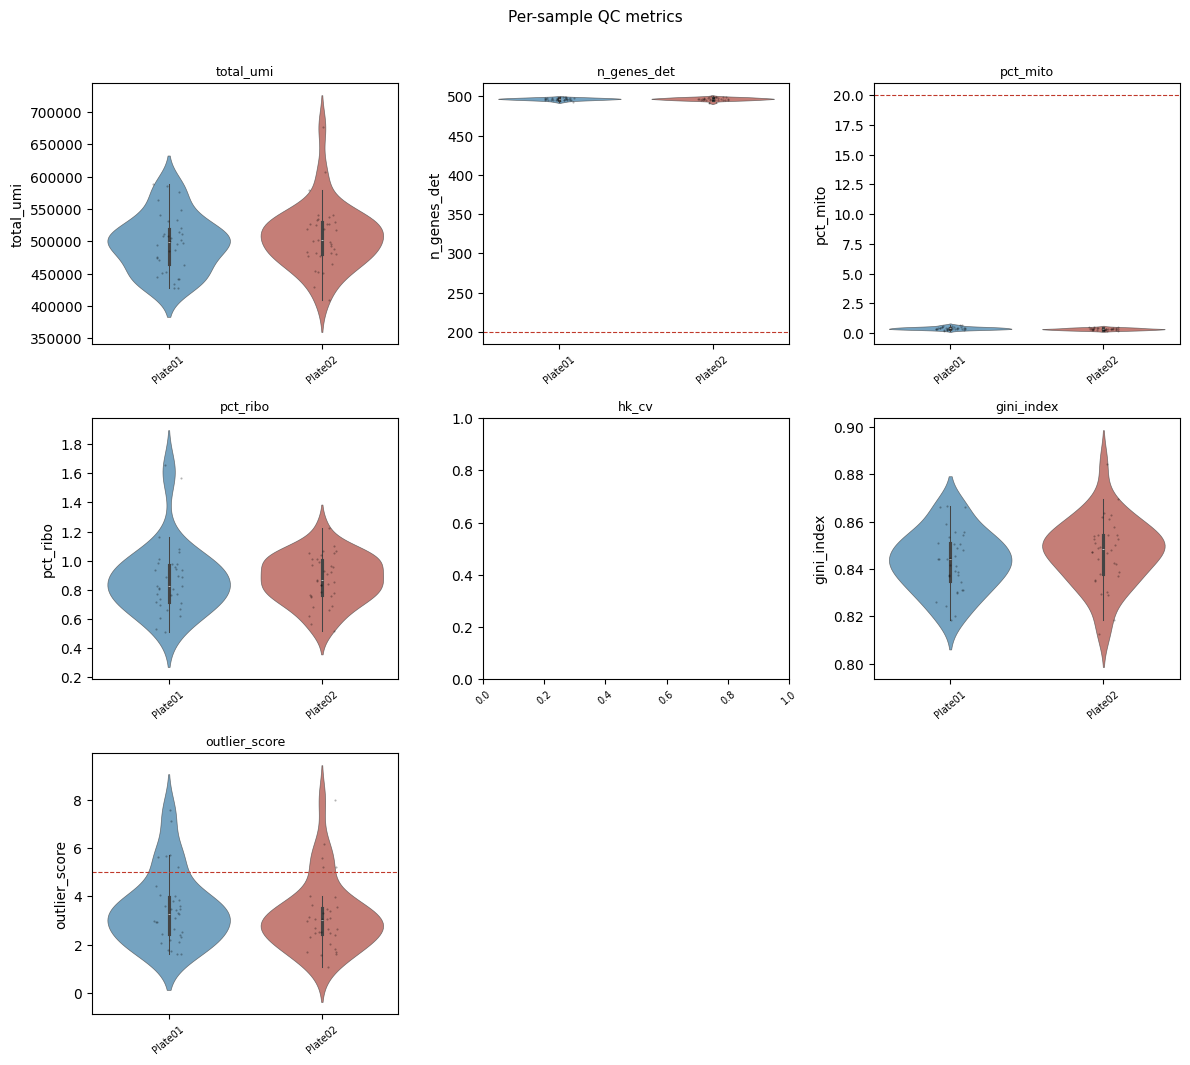

In [6]:
fig = ds.plot_qc_summary(
    dsd,
    metrics=['total_umi','n_genes_det','pct_mito','pct_ribo','hk_cv','gini_index','outlier_score'],
    group_by='plate_id',
    thresholds={'pct_mito': 20, 'n_genes_det': 200, 'outlier_score': 5},
)
plt.show()

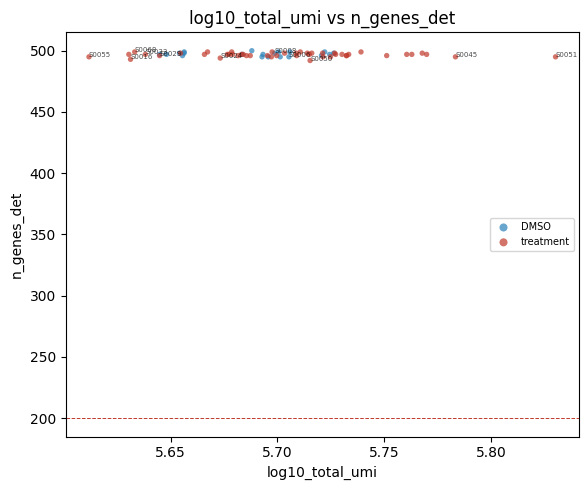

In [7]:
# Bivariate scatter: UMI vs detected genes
fig = ds.plot_qc_scatter(dsd, x_metric='log10_total_umi', y_metric='n_genes_det',
                          color_by='sample_type', y_threshold=200)
plt.show()

## 4. Plate-level QC

Z'-factor > 0.5 = excellent assay; spatial heatmaps reveal edge effects.

In [8]:
ds.compute_plate_qc(dsd, signal_col='log10_total_umi', neg_ctrl_label='DMSO', inplace=True)
print(ds.plate_qc_summary(dsd)[['plate_id','zprime','ssmd','dmso_cv','dmso_cor','flag']])

Plate QC computed for 2 plate(s): 0 pass, 2 warn, 0 fail.
  plate_id  zprime  ssmd   dmso_cv  dmso_cor  flag
0  Plate01     NaN   NaN  0.432414  0.937114  warn
1  Plate02     NaN   NaN  0.444861  0.936613  warn


In [9]:
dsd.adata

AnnData object with n_obs × n_vars = 68 × 500
    obs: 'plate_id', 'compound', 'dose', 'dose_unit', 'sample_type', 'well_id', 'total_umi', 'log10_total_umi', 'n_genes_det', 'genes_per_umi', 'pct_mito', 'pct_ribo', 'hk_mean_log', 'hk_cv', 'hk_dropout_frac', 'gini_index', 'outlier_score'
    var: 'is_mito', 'is_ribo'
    uns: 'norm_method', 'de_results', 'plate_qc', 'gsea'
    layers: 'counts'

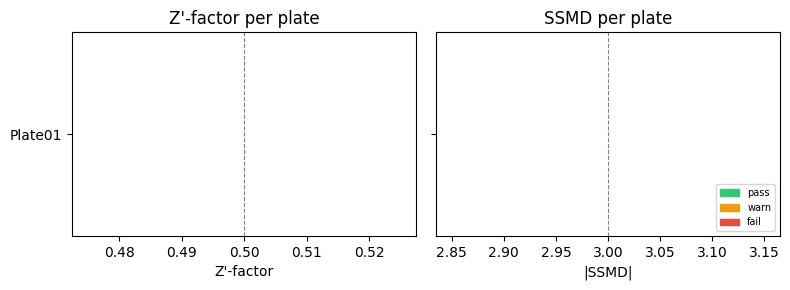

In [10]:
fig = ds.plot_zprime(dsd, show_ssmd=True)
plt.show()

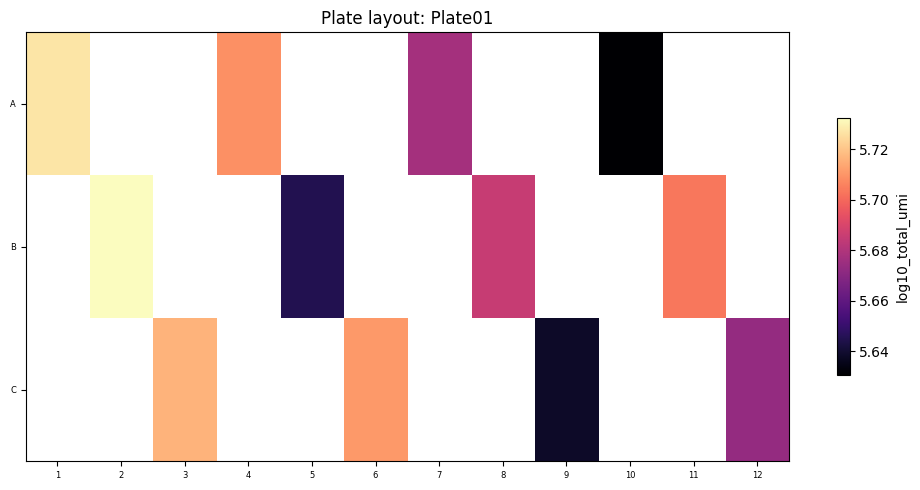

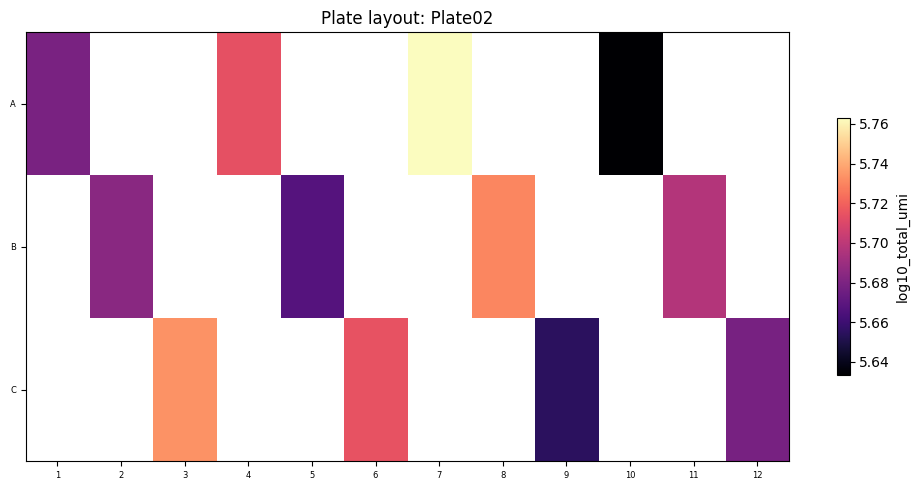

In [11]:
# Spatial heatmaps — one per plate
for pid in dsd.adata.uns['plate_qc']:
    fig = ds.plot_plate_heatmap(dsd, plate_id=pid, value_col='log10_total_umi')
    plt.title(f'Plate layout: {pid}')
    plt.show()

## 5. Group-level QC and replicate ICC

Mirrors macpie's `compute_qc_metrics()` group-level statistics.
ICC (intra-class correlation) > 0.8 = replicates are highly consistent.

In [12]:
grp_qc = ds.compute_group_qc(dsd, group_by='compound', readout_col='total_umi')
print(grp_qc[['compound','group_median','sd_value','mad_value','z_score','cv_pct']].to_string())

  compound  group_median      sd_value  mad_value   z_score     cv_pct
0   Cmpd06      463561.0  55255.210691    31405.0 -1.502101  11.572217
1   Cmpd03      484453.0  41953.871624    18771.0 -0.498908   8.624842
2   Cmpd04      490683.0  26289.824510    13987.0 -0.199755   5.277531
3     DMSO      494843.0  30167.037136    21919.0  0.000000   6.166709
4   Cmpd05      515668.5  33073.031189     4331.0  1.000000   6.567054
5   Cmpd01      519067.0  41479.221858    22166.0  1.163189   7.874103
6   Cmpd02      558098.0  71176.350970    29208.0  3.037382  12.801709


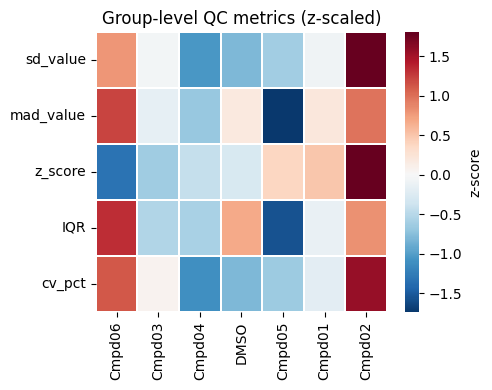

In [13]:
fig = ds.plot_group_qc_heatmap(grp_qc)
plt.show()

In [14]:
icc = ds.compute_replicate_icc(dsd, group_by='compound', metric='total_umi')
print(f'\nICC = {icc["icc"]:.3f}  (> 0.8 indicates good replicate consistency)')
print(icc['per_group_cv'])

Replicate ICC (compound, metric=total_umi): 0.206

ICC = 0.206  (> 0.8 indicates good replicate consistency)
  compound   n     cv_pct
0   Cmpd01   8   7.874103
1   Cmpd02   8  12.801709
2   Cmpd03   8   8.624842
3   Cmpd04   8   5.277531
4   Cmpd05   8   6.567054
5   Cmpd06   8  11.572217
6     DMSO  20   6.166709


## 6. Select robust DMSO controls

Filters DMSO wells by TMMwsp Pearson correlation — mirrors macpie's `select_robust_controls()`.

In [15]:
good_ctrl = ds.select_robust_controls(dsd, neg_ctrl_label='DMSO', min_cor=0.80)
print(f'Robust DMSO wells ({len(good_ctrl)}): {good_ctrl[:5]}...')

select_robust_controls: retaining 20 / 20 control wells (min_cor=0.80).
Robust DMSO wells (20): ['S0001', 'S0002', 'S0003', 'S0004', 'S0005']...


## 7. Normalization comparison

`limma_voom` typically achieves the lowest RLE deviation and CV for HTTr data
(validated by macpie benchmarks on MAC-seq data).

    method  median_rle_center  median_rle_iqr  mean_cv
       CPM             0.0823          0.8872   0.1097
       TMM             0.0624          0.8966   0.1090
limma_voom             0.0624          0.8966   0.1090


/Users/frankhuang/Documents/HKU-RA/01.Library-Seq/20260317/drugseqpy/src/drugseqpy/normalization.py:329: UserWarning: Unknown method 'log1p'; skipping.
  warnings.warn(f"Unknown method '{meth}'; skipping.")


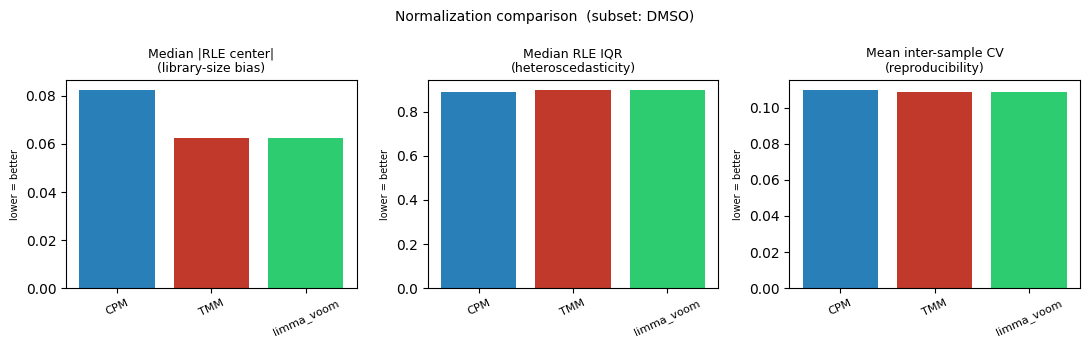

In [16]:
# Side-by-side comparison of normalization methods
fig = ds.plot_norm_comparison(dsd, methods=['log1p','CPM','TMM','limma_voom'], subset_type='DMSO')
plt.show()

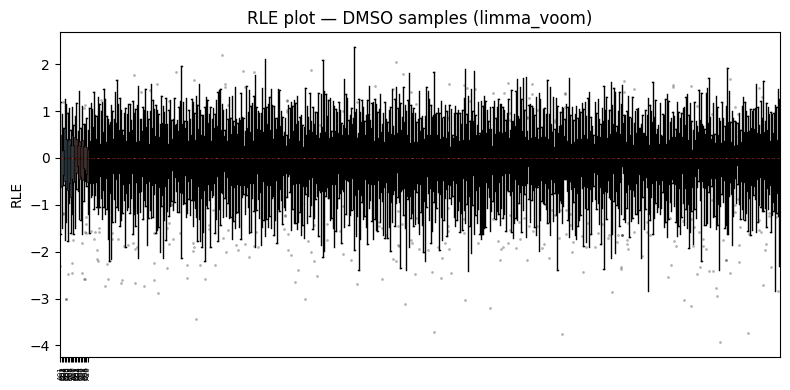

In [17]:
# RLE plot for DMSO wells — boxes centered on 0 = good normalization
fig = ds.plot_rle(dsd, subset_type='DMSO', normalization='limma_voom',
                   label_col='well_id', color_col='plate_id')
plt.show()

## 8. Normalize, filter, and save

In [18]:
# Apply limma_voom normalization (default, recommended)
ds.normalize_counts(dsd, method='limma_voom', inplace=True)

Normalizing 500 genes × 68 samples using limma_voom.
Normalization complete (method=limma_voom).


In [19]:
# Filter low-quality samples
dsd_f = ds.filter_samples(dsd, min_umi=3000, max_pct_mito=20, max_outlier_score=8)
print(f'After sample filtering: {dsd_f.n_obs} samples remain')

filter_samples: keeping 67 / 68 samples (1 removed).
  outlier           : 1 sample(s)
After sample filtering: 67 samples remain


In [20]:
# Group-aware gene filtering (macpie::filter_genes_by_expression strategy)
# A gene is kept if expressed in >= 1 compound group, preventing removal
# of drug-induced genes that are off in DMSO controls.
dsd_f = ds.filter_genes(dsd_f, min_count=5, min_samples=2,
                          group_aware=True, group_col='compound')
print(f'After gene filtering: {dsd_f.n_vars} genes remain')

filter_genes: retaining 496 / 500 genes (4 removed).
  Low-expression removed: 4
After gene filtering: 496 genes remain


/Users/frankhuang/miniforge3/envs/drugseqpy/lib/python3.10/site-packages/sklearn/manifold/_mds.py:677: FutureWarning: The default value of `n_init` will change from 4 to 1 in 1.9.
  warnings.warn(


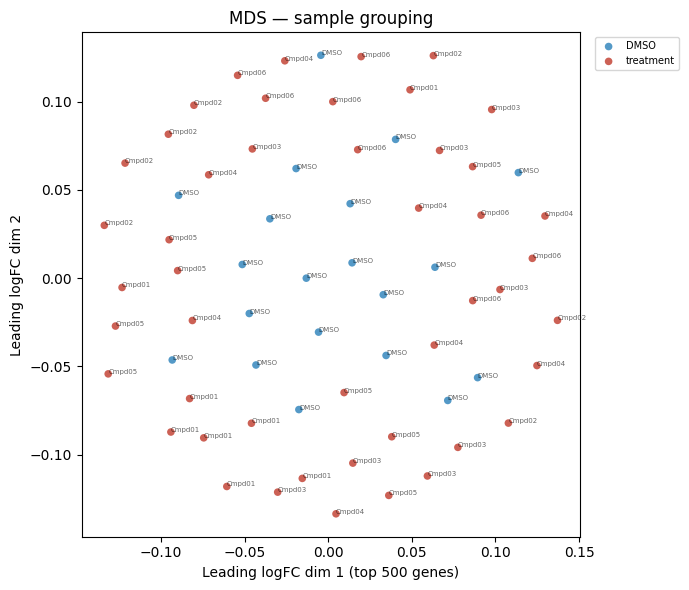

In [21]:
# MDS for sample grouping (macpie::plot_mds approach)
# Better than PCA for initial QC: uses leading log-fold-change distances
fig = ds.plot_mds(dsd_f, group_by='sample_type', label_by='compound')
plt.show()

In [24]:
# Save filtered object
# dsd_f.adata.write_h5ad('dsd_qc_filtered.h5ad')
dsd_f.write('dsd_qc_filtered.h5ad')
print('Saved: dsd_qc_filtered.h5ad')
# load data
from drugseqpy.core import DrugSeqData
dsd_f=DrugSeqData.read_h5ad('dsd_qc_filtered.h5ad')

Saved: dsd_qc_filtered.h5ad


In [26]:
dsd_f.adata

AnnData object with n_obs × n_vars = 67 × 496
    obs: 'plate_id', 'compound', 'dose', 'dose_unit', 'sample_type', 'well_id', 'total_umi', 'log10_total_umi', 'n_genes_det', 'genes_per_umi', 'pct_mito', 'pct_ribo', 'hk_mean_log', 'hk_cv', 'hk_dropout_frac', 'gini_index', 'outlier_score'
    var: 'is_mito', 'is_ribo'
    uns: '__is_drugseq_data__', 'de_results', 'gsea', 'norm_method', 'plate_qc'
    layers: 'counts'

---
**Next →** `02_Screen_Analysis.ipynb`